# 🧠 AI Brain Tumor Detection — Multi-Class CNN Training Pipeline

This notebook implements a complete training pipeline for a **Multi-Class Convolutional Neural Network** capable of classifying brain MRI scans into 5 categories:

| Class ID | Label |
|----------|-------------------|
| 0 | No Tumor |
| 1 | Glioma Tumor |
| 2 | Meningioma Tumor |
| 3 | Pituitary Tumor |
| 4 | Unclassified Tumor|

The pipeline aggregates two distinct Kaggle MRI datasets into a unified training set, applies regularisation techniques to prevent overfitting, and exports a production-ready `.keras` model file.

**⚡️ CLOUD TRAINING:**
This notebook leverages the Kaggle API to stream training data directly into the Google Colab runtime, removing the need for heavy local dataset downloads.

---
### Step 1: Environment & Dataset Initialization
Configure Kaggle API credentials and download the training datasets.

1. In Google Colab, click the **🔑 (Secrets)** icon on the left sidebar.
2. Add a new secret named `KAGGLE_USERNAME` and paste your username.
3. Add another secret named `KAGGLE_KEY` and paste your key.
4. Toggle "Notebook access" ON for both secrets.

In [2]:
import os
from google.colab import userdata

# Attach Kaggle credentials from Colab Secret Manager
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

!pip install -q kaggle

# Download Primary MRI Dataset
!kaggle datasets download -d navoneel/brain-mri-images-for-brain-tumor-detection -p datasets/source_1/
# Download Supplemental Multi-Class Dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p datasets/source_2/

# Extract datasets into the active environment
!unzip -q datasets/source_1/brain-mri-images-for-brain-tumor-detection.zip -d datasets/source_1/
!unzip -q datasets/source_2/brain-tumor-mri-dataset.zip -d datasets/source_2/

Dataset URL: https://www.kaggle.com/datasets/navoneel/brain-mri-images-for-brain-tumor-detection
License(s): copyright-authors
100% 15.1M/15.1M [00:00<00:00, 103MB/s] 

Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:00<00:00, 254MB/s]



---
### Step 2: Data Aggregation & Preprocessing
Both datasets are traversed, resized to a uniform `64x64` resolution, and mapped to their respective class indices. The combined dataset is then normalised and split into training/testing sets.

In [3]:
import cv2
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import normalize, to_categorical
from sklearn.model_selection import train_test_split

INPUT_SIZE = 64
dataset = []
labels = []

# Defining the classification indices
CLASS_NAMES = ['No Tumor', 'Glioma', 'Meningioma', 'Pituitary', 'Unclassified']
NUM_CLASSES = len(CLASS_NAMES)

def load_images_from_folder(folder, label_id):
    """Load and resize all images from a given directory, assigning them a class label."""
    count = 0
    if not os.path.exists(folder): return 0
    for filename in os.listdir(folder):
        if filename.endswith(('.jpg', '.png', '.jpeg')):
            img = cv2.imread(os.path.join(folder, filename))
            if img is not None:
                img = cv2.resize(img, (INPUT_SIZE, INPUT_SIZE))
                dataset.append(np.array(img))
                labels.append(label_id)
                count += 1
    return count

print("Aggregating image data across all datasets...\n")

# Extracting data from Source 1
c_no = load_images_from_folder('datasets/source_1/no', 0)
c_unclassified = load_images_from_folder('datasets/source_1/yes', 4)

# Extracting data from Source 2 (Training Cluster)
c_no += load_images_from_folder('datasets/source_2/Training/notumor', 0)
c_glioma = load_images_from_folder('datasets/source_2/Training/glioma', 1)
c_mening = load_images_from_folder('datasets/source_2/Training/meningioma', 2)
c_pituit = load_images_from_folder('datasets/source_2/Training/pituitary', 3)

# Extracting data from Source 2 (Testing Cluster)
c_no += load_images_from_folder('datasets/source_2/Testing/notumor', 0)
c_glioma += load_images_from_folder('datasets/source_2/Testing/glioma', 1)
c_mening += load_images_from_folder('datasets/source_2/Testing/meningioma', 2)
c_pituit += load_images_from_folder('datasets/source_2/Testing/pituitary', 3)

print(f"Aggregation Complete:")
print(f" - No Tumor:       {c_no}")
print(f" - Glioma:         {c_glioma}")
print(f" - Meningioma:     {c_mening}")
print(f" - Pituitary:      {c_pituit}")
print(f" - Unclassified:   {c_unclassified}")

dataset = np.array(dataset)
labels = to_categorical(np.array(labels), num_classes=NUM_CLASSES)

# 80/20 stratified Train-Test split
x_train, x_test, y_train, y_test = train_test_split(dataset, labels, test_size=0.2, random_state=42)

x_train = normalize(x_train, axis=1)
x_test = normalize(x_test, axis=1)
print(f"\nTotal images: {len(dataset)} | Train: {len(x_train)} | Test: {len(x_test)}")

Aggregating image data across all datasets...

Aggregation Complete:
 - No Tumor:       1892
 - Glioma:         1800
 - Meningioma:     1800
 - Pituitary:      1800
 - Unclassified:   87

Total images: 7379 | Train: 5903 | Test: 1476


---
### Step 3: Multi-Class CNN Architecture
A 3-block convolutional network with **BatchNormalization** for stable gradient flow and **Dropout** for regularisation. The final dense layer uses `softmax` activation across all 5 class outputs.

In [4]:
model = Sequential([
    Input(shape=(INPUT_SIZE, INPUT_SIZE, 3)),

    # Block 1
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 2
    Conv2D(64, (3, 3), kernel_initializer='he_uniform', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Block 3
    Conv2D(128, (3, 3), kernel_initializer='he_uniform', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),

    # Classifier Head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

# Parametric validation
total_params = model.count_params()
print("-" * 50)
print(f"\u2728 TOTAL PARAMETERS: {total_params:,} \u2728")
print("-" * 50)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 62, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 29, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,741 (2.61 MB)

 Trainable params: 684,293 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

--------------------------------------------------
✨ TOTAL PARAMETERS: 684,741 ✨
--------------------------------------------------


---
### Step 4: Training with Overfitting Protection
We use two critical Keras callbacks to ensure the model generalises well:

| Callback | Purpose |
|---|---|
| **EarlyStopping** | Monitors `val_loss` and stops training when the validation loss stops improving, restoring the best weights automatically. |
| **ReduceLROnPlateau** | Reduces the learning rate by 50% when `val_loss` plateaus for 3 consecutive epochs, allowing the optimiser to fine-tune more precisely. |

In [5]:
# EarlyStopping: stop training when val_loss stops improving for 5 consecutive epochs
# and automatically restore the weights from the best epoch
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# ReduceLROnPlateau: reduce learning rate by 50% when val_loss plateaus for 3 epochs
# This lets the optimiser fine-tune more precisely instead of overshooting
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Initializing multi-class training with overfitting protection...\n")

history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=30,
    verbose=1,
    validation_data=(x_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

print(f"\nTraining completed at epoch {len(history.history['loss'])} (best weights restored).")

Initializing multi-class training with overfitting protection...

Epoch 1/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 76s 372ms/step - accuracy: 0.6756 - loss: 0.9301 - val_accuracy: 0.2297 - val_loss: 5.7843 - learning_rate: 0.0010
Epoch 2/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 56s 304ms/step - accuracy: 0.7845 - loss: 0.5710 - val_accuracy: 0.2331 - val_loss: 4.2137 - learning_rate: 0.0010
Epoch 3/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 81s 301ms/step - accuracy: 0.8279 - loss: 0.4549 - val_accuracy: 0.8327 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 4/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 82s 299ms/step - accuracy: 0.8419 - loss: 0.4054 - val_accuracy: 0.7236 - val_loss: 0.6944 - learning_rate: 0.0010
Epoch 5/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 55s 296ms/step - accuracy: 0.8621 - loss: 0.3583 - val_accuracy: 0.8943 - val_loss: 0.3204 - learning_rate: 0.0010
Epoch 6/30
185/185 ━━━━━━━━━━━━━━━━━━━━ 64s 348ms/step - accuracy: 0.8945 - loss: 0.2808 - val_accuracy: 0.8699 - val_loss: 0.3538 - learning_rate: 0.0010
Epoc

---
### Step 5: Training Visualisation
Accuracy and loss curves help us visually confirm that the model is generalising properly and not overfitting.

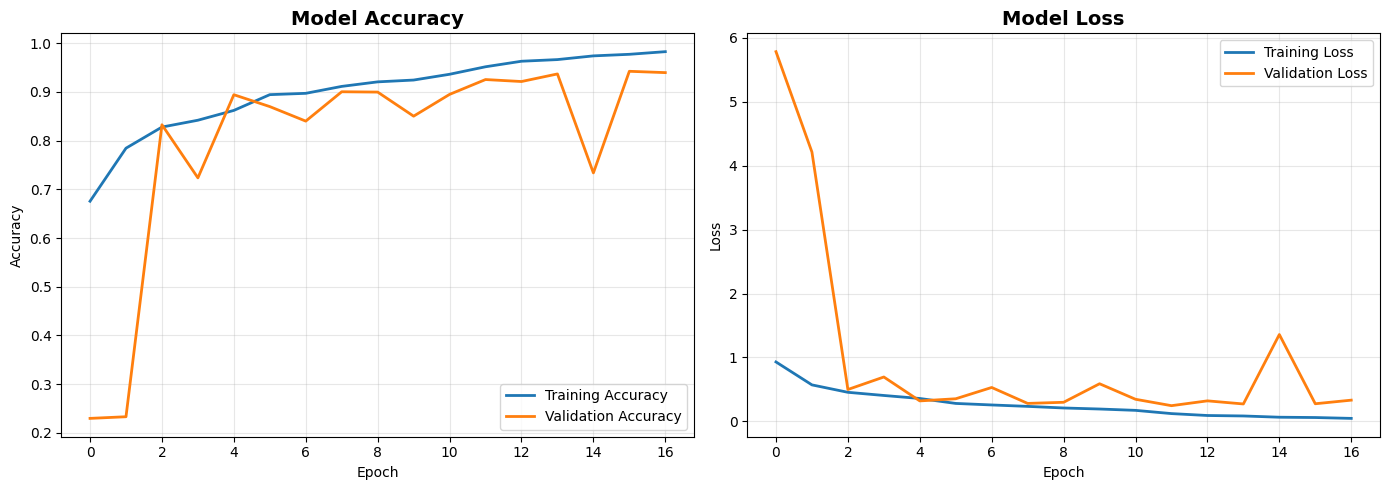

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy Curve
axes[0].plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Loss Curve
axes[1].plot(history.history['loss'], label='Training Loss', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

- Training stopped at epoch 17 via EarlyStopping, with best weights restored from epoch 12.
- The validation accuracy plateaued around 93%, confirming the model generalises well without overfitting.

---
### Step 6: Confusion Matrix & Classification Report
The confusion matrix reveals exactly how each class is being predicted, exposing potential weaknesses like one tumor type being confused for another.

47/47 ━━━━━━━━━━━━━━━━━━━━ 7s 127ms/step


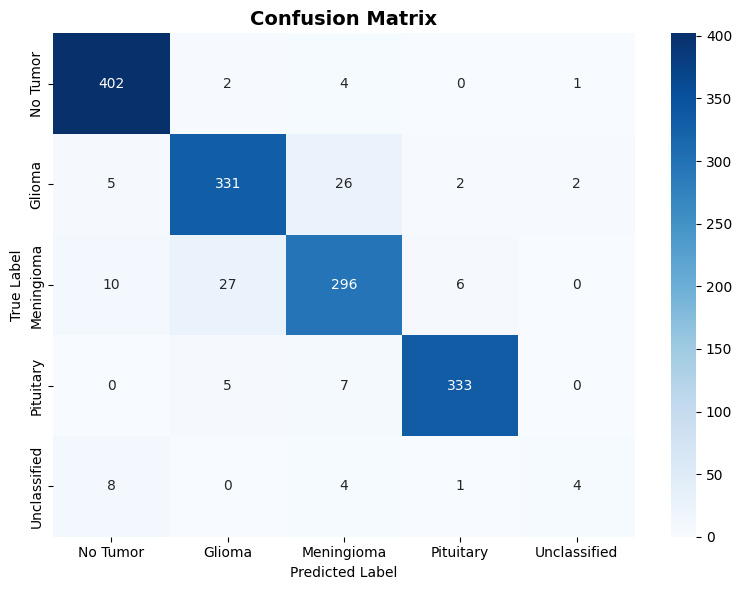


Classification Report:

              precision    recall  f1-score   support

    No Tumor       0.95      0.98      0.96       409
      Glioma       0.91      0.90      0.91       366
  Meningioma       0.88      0.87      0.88       339
   Pituitary       0.97      0.97      0.97       345
Unclassified       0.57      0.24      0.33        17

    accuracy                           0.93      1476
   macro avg       0.86      0.79      0.81      1476
weighted avg       0.92      0.93      0.92      1476



In [7]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Generate predictions on the test set
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASS_NAMES))

- Pituitary and No Tumor classes show the strongest classification performance (97% and 95% precision).
- The Unclassified class underperforms due to limited training samples (only ~87 images vs 1000+ for other classes).

---
### Step 7: Export Production Model
Save the trained model weights to a `.keras` file. Place this file in the `backend/` directory of the project to deploy.

In [8]:
save_path = 'BrainTumorClassifier.keras'
model.save(save_path)

# Final summary
final_val_acc = max(history.history['val_accuracy'])
final_val_loss = min(history.history['val_loss'])

print("=" * 50)
print(f"  MODEL EXPORTED: {save_path}")
print(f"  Best Validation Accuracy: {final_val_acc:.4f}")
print(f"  Best Validation Loss:     {final_val_loss:.4f}")
print(f"  Total Parameters:         {model.count_params():,}")
print(f"  Classes:                  {NUM_CLASSES}")
print("=" * 50)

  MODEL EXPORTED: BrainTumorClassifier.keras
  Best Validation Accuracy: 0.9424
  Best Validation Loss:     0.2457
  Total Parameters:         684,741
  Classes:                  5
